In [1]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.8 MB/s eta 0:00:00


In [2]:
!pip install kaggle


In [3]:
#Upload kaggle.json dulu lewat file upload Colab
from google.colab import files
uploaded = files.upload()  # pilih kaggle.json

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

#  Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Extract zip
import zipfile
with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")



Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:23<00:00, 216MB/s]
100% 2.29G/2.29G [00:23<00:00, 103MB/s]


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [5]:
train_dir = "/content/chest_xray/train"

rows = []
for label in ["NORMAL", "PNEUMONIA"]:
    folder = os.path.join(train_dir, label)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.png','.jpg','.jpeg')):
            rows.append({"filepath": os.path.join(folder, fname), "label": label})

df = pd.DataFrame(rows)

In [6]:
df_subset = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=1000, random_state=42))
      .reset_index(drop=True)
)
print("Subset distribution:\n", df_subset['label'].value_counts())


Subset distribution:
 label
NORMAL       1000
PNEUMONIA    1000
Name: count, dtype: int64


/tmp/ipykernel_446/2557216890.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1000, random_state=42))


In [7]:
train_df, temp_df = train_test_split(
    df_subset,
    test_size=0.30,  # 30% sisa untuk val+test
    stratify=df_subset['label'],
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% dari 30% = 15%
    stratify=temp_df['label'],
    random_state=42,
    shuffle=True
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train label distribution:\n", train_df['label'].value_counts())
print("Val label distribution:\n", val_df['label'].value_counts())
print("Test label distribution:\n", test_df['label'].value_counts())

Train: 1400 Val: 300 Test: 300
Train label distribution:
 label
NORMAL       700
PNEUMONIA    700
Name: count, dtype: int64
Val label distribution:
 label
PNEUMONIA    150
NORMAL       150
Name: count, dtype: int64
Test label distribution:
 label
PNEUMONIA    150
NORMAL       150
Name: count, dtype: int64


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generator training
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath',
    y_col='label', target_size=IMAGE_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True, seed=42 )

# Generator validasi
val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False, seed=42 )

# Generator testing
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False, seed=42 )

Found 1400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


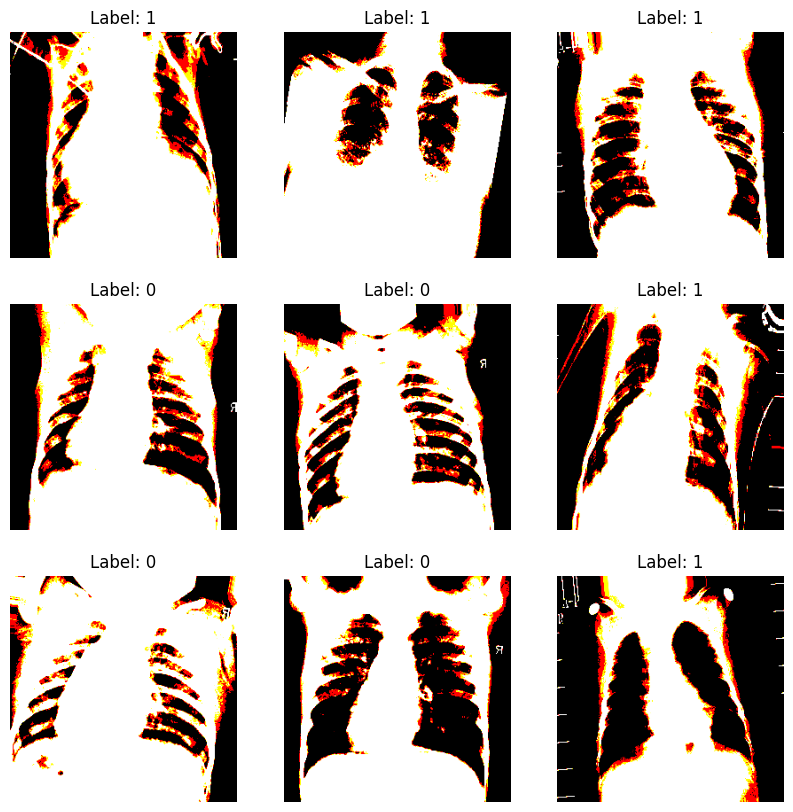

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil satu batch data dari generator
images, labels = next(train_gen)

# Tampilkan 9 contoh gambar
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")
plt.show()


Found 1400 validated image filenames belonging to 2 classes.


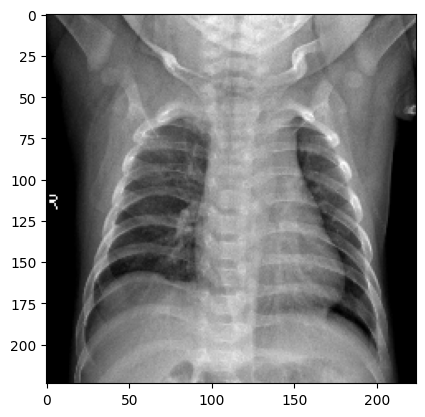

In [28]:
viz_datagen = ImageDataGenerator(rescale=1./255)

viz_gen = viz_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224,224),
    class_mode='binary'
)
images, labels = next(viz_gen)
plt.imshow(images[0])

In [29]:
labels = train_df['label'].map({'NORMAL':0, 'PNEUMONIA':1}).values
classes = np.unique(labels)
class_weights = compute_class_weight('balanced', classes=classes, y=labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [41]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

# Base model: ResNet50 pretrained dari ImageNet
base = ResNet50(weights="imagenet", include_top=False, input_shape=(256, 256, 3))

# Tahap 1: Feature Extraction
base.trainable = False  # freeze semua layer ResNet50

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(256, activation="relu")(x)          # tambahan layer dense agar lebih kuat
x = layers.BatchNormalization()(x)                   # stabilkan aktivasi & percepat training
x = layers.Dropout(0.5)(x)                           # dropout sedikit lebih besar untuk cegah overfitting
out = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=base.input, outputs=out)

# 🔧 Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [42]:
train_df['label'].value_counts(), val_df['label'].value_counts(), test_df['label'].value_counts()


(label
 NORMAL       700
 PNEUMONIA    700
 Name: count, dtype: int64,
 label
 PNEUMONIA    150
 NORMAL       150
 Name: count, dtype: int64,
 label
 PNEUMONIA    150
 NORMAL       150
 Name: count, dtype: int64)

In [43]:
# @title
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
  ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_auc", mode="max"),
  #EarlyStopping(monitor="val_auc", patience=5, restore_best_weights=True),
  ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]

# setelah feature-extraction selesai:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

history = model.fit(train_gen, validation_data=val_gen,
                    epochs=10, callbacks=callbacks, class_weight=class_weight_dict)


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6848 - auc: 0.7521 - loss: 0.6301 - val_accuracy: 0.9533 - val_auc: 0.9868 - val_loss: 0.2937 - learning_rate: 1.0000e-05
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9060 - auc: 0.9656 - loss: 0.2355 - val_accuracy: 0.9433 - val_auc: 0.9942 - val_loss: 0.1984 - learning_rate: 1.0000e-05
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9245 - auc: 0.9765 - loss: 0.1943 - val_accuracy: 0.9467 - val_auc: 0.9972 - val_loss: 0.1580 - learning_rate: 1.0000e-05
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9474 - auc: 0.9886 - loss: 0.1332 - val_accuracy: 0.9600 - val_auc: 0.9983 - val_loss: 0.1134 - learning_rate: 1.0000e-05
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9454 - auc: 0.9840 - loss: 0.1589 - val_accuracy: 0.9733 - val_auc: 0.9992 - val_loss: 0.0876 - learning_rate: 1.0000e-05
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9612 -

In [44]:
base.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9676 - auc: 0.9939 - loss: 0.0878 - val_accuracy: 0.9767 - val_auc: 0.9998 - val_loss: 0.0678 - learning_rate: 1.0000e-05
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 882ms/step - accuracy: 0.9745 - auc: 0.9974 - loss: 0.0648 - val_accuracy: 0.9800 - val_auc: 0.9997 - val_loss: 0.0637 - learning_rate: 1.0000e-05
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 886ms/step - accuracy: 0.9789 - auc: 0.9986 - loss: 0.0544 - val_accuracy: 0.9800 - val_auc: 0.9997 - val_loss: 0.0621 - learning_rate: 1.0000e-05
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 882ms/step - accuracy: 0.9801 - auc: 0.9986 - loss: 0.0513 - val_accuracy: 0.9833 - val_auc: 0.9997 - val_loss: 0.0601 - learning_rate: 1.0000e-05
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9813 - auc: 0.9979 - loss: 0.0497 - val_accuracy: 0.9833 - val_auc: 0.9998 - val_loss: 0.0569 - learning_rate: 1.0000e-05
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy:

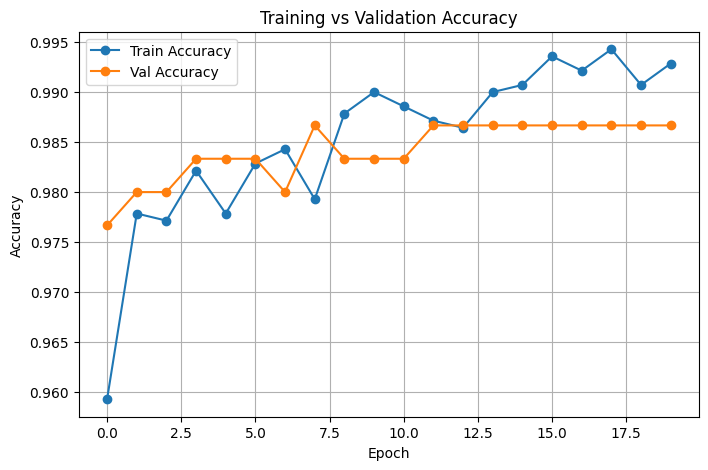

In [45]:
import matplotlib.pyplot as plt

# --- Akurasi ---
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


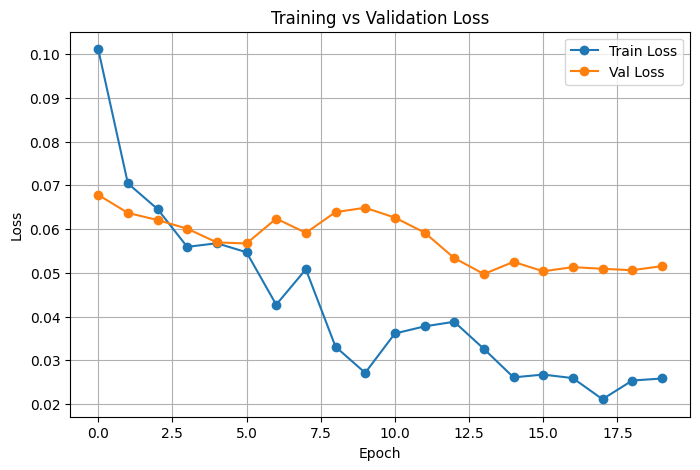

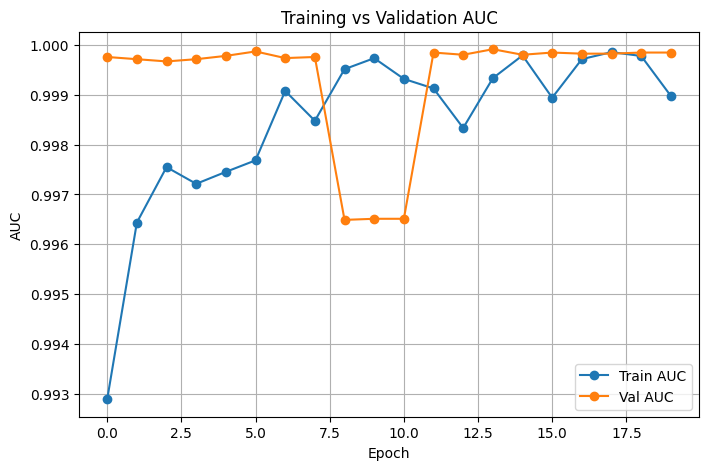

In [46]:

# --- Loss ---
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss', marker='o')
plt.plot(history2.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- AUC ---
plt.figure(figsize=(8,5))
plt.plot(history2.history['auc'], label='Train AUC', marker='o')
plt.plot(history2.history['val_auc'], label='Val AUC', marker='o')
plt.title('Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [47]:
test_loss, test_auc, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

y_true = test_gen.classes
y_pred = model.predict(test_gen).ravel()
y_pred_classes = (y_pred > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
print(classification_report(y_true, y_pred_classes, target_names=["NORMAL","PNEUMONIA"]))
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.9896 - auc: 0.9998 - loss: 0.0262
Test Accuracy: 0.9833 | Test AUC: 0.9998
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 769ms/step
              precision    recall  f1-score   support

      NORMAL       0.97      0.99      0.98       150
   PNEUMONIA       0.99      0.97      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

Confusion Matrix:
 [[149   1]
 [  4 146]]


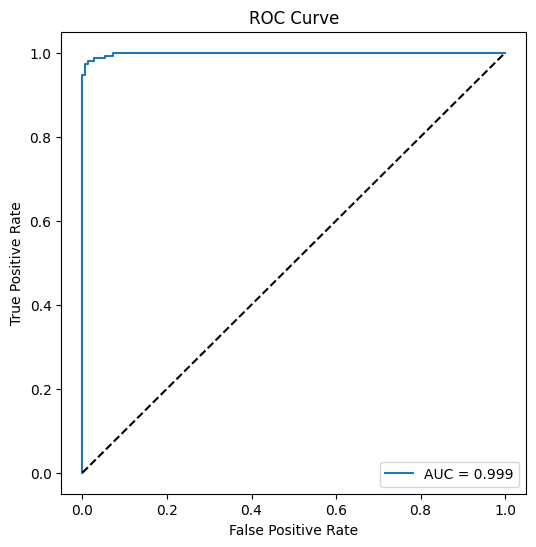

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

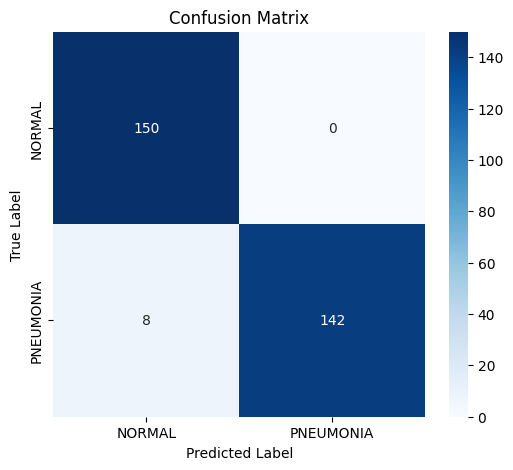

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Misal cm sudah ada (confusion matrix numpy array)
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 349ms/step
False Positive: 0
False Negative: 8
Tidak ada gambar false positive (normal diprediksi pneumonia)


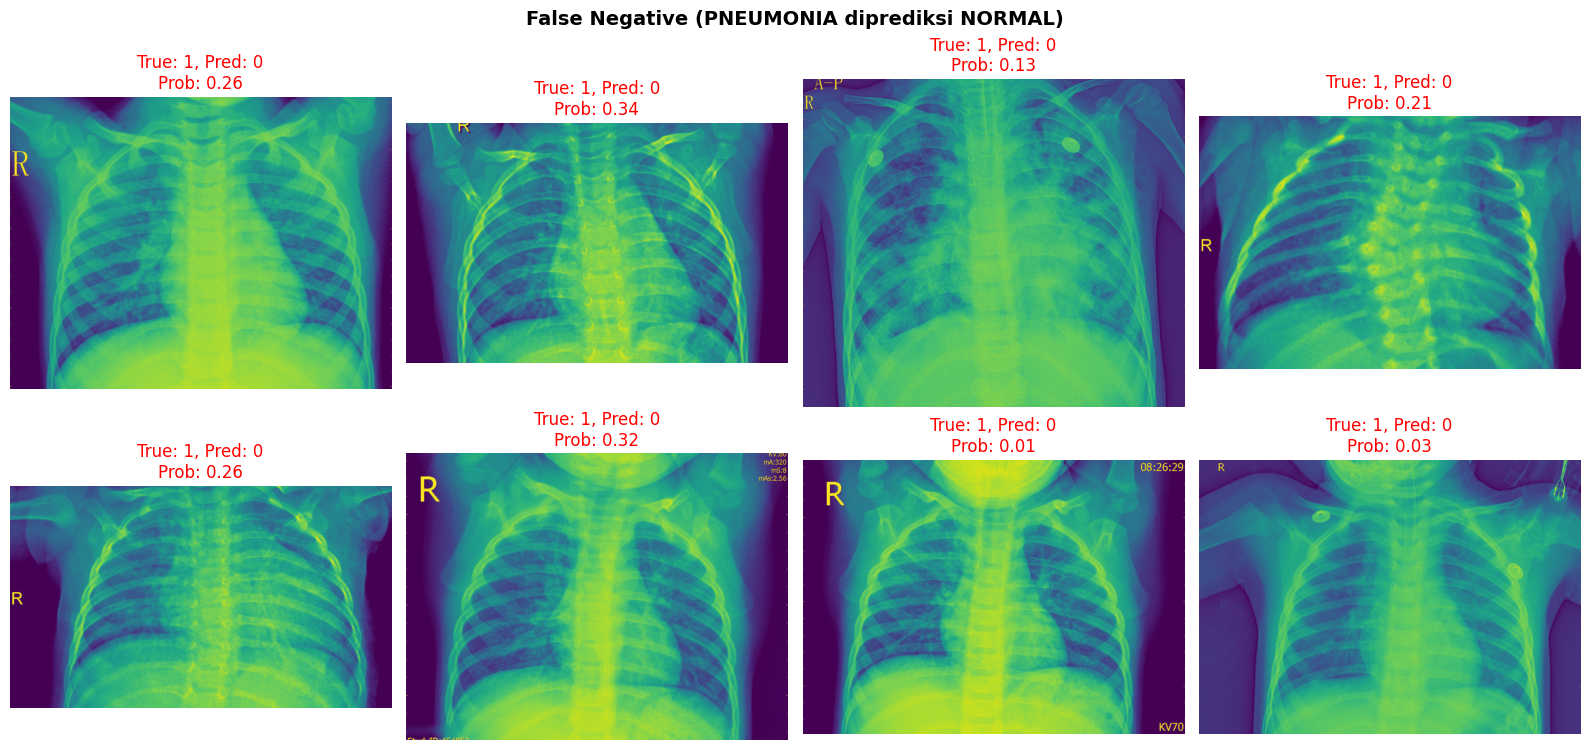

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. Prediksi pada data test ---
test_gen.reset()
pred_probs = model.predict(test_gen, verbose=1)
pred_labels = (pred_probs > 0.5).astype(int).flatten()

# --- 2. DataFrame hasil prediksi ---
results_df = pd.DataFrame({
    'filepath': test_gen.filepaths,
    'true_label': test_gen.classes,
    'pred_label': pred_labels,
    'prob': pred_probs.flatten()
})

# --- 3. Filter sesuai confusion matrix ---
false_positive = results_df[(results_df['true_label'] == 0) & (results_df['pred_label'] == 1)]  # NORMAL → PNEUMONIA
false_negative = results_df[(results_df['true_label'] == 1) & (results_df['pred_label'] == 0)]  # PNEUMONIA → NORMAL

print(f"False Positive: {len(false_positive)}")
print(f"False Negative: {len(false_negative)}")

# --- 4. Fungsi tampilkan gambar ---
def show_images(df, title, ncols=4):
    n = len(df)
    if n == 0:
        print(f"Tidak ada gambar {title.lower()}")
        return

    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 4*nrows))

    for i, row in enumerate(df.itertuples(), 1):
        img = plt.imread(row.filepath)
        plt.subplot(nrows, ncols, i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {row.true_label}, Pred: {row.pred_label}\nProb: {row.prob:.2f}", color='red')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- 5. Tampilkan kedua jenis kesalahan ---
show_images(false_positive, "False Positive (NORMAL diprediksi PNEUMONIA)")
show_images(false_negative, "False Negative (PNEUMONIA diprediksi NORMAL)")
